# Laboratorio 03 — La métrica que importa

**Curso:** Analítica Empresarial Integrada · **Periodo:** 2026-II  
**Estudiante:** Jhadir Abdel Yupanqui Chahua · **Sección:** C28 6to A-L  
**Docente:** Pilar Rocío Sayán Mejía · **Fecha:** 6 de septiembre de 2026  
**Fuente:** UCI Machine Learning Repository — Online Retail, ID 352.

## Propósito y principales resultados

Desarrollo un sistema que conecta objetivo, North Star, drivers, guardrails y decisión. Trabajo con **541 909 registros reales**, conservo la fuente y uso enero-noviembre de 2011 como ventana de análisis.

- La mayor caída comparable de compras recurrentes se presenta en **junio: −9,44 %**, de 1 271 a 1 151.
- En junio disminuyen los clientes recurrentes (−4,45 %) y la frecuencia (−5,22 %), mientras el ticket recurrente aumenta 11,23 %.
- **Cuatro meses** cumplen la regla académica de crecimiento positivo y cancelación inferior a la media mensual: mayo, septiembre, octubre y noviembre.


---

## Agenda de laboratorio — 7:00 p. m. a 10:10 p. m.

**Duración total:** 190 minutos · **Receso:** 15 minutos · **Trabajo efectivo:** 175 minutos.

| Horario | Tiempo | Desarrollo |
|---|---:|---|
| 7:00–7:10 | 10 min | Apertura del caso y presentación del problema de medición. |
| 7:10–7:35 | 25 min | Actividad 1. Revisión de conceptos: del dato a la decisión. |
| 7:35–8:00 | 25 min | Actividad 2. Descarga desde UCI, auditoría y limpieza documentada. |
| 8:00–8:30 | 30 min | Actividad 2. Periodo comparable, recurrencia y North Star. Reto 1. |
| 8:30–8:45 | 15 min | **RECESO** |
| 8:45–9:15 | 30 min | Actividad 2. Árbol de métricas, guardrails, Polars y DuckDB. |
| 9:15–9:35 | 20 min | Actividad 2. Tablero de decisión en Plotly. Reto 2. |
| 9:35–10:00 | 25 min | **Reto de aplicación y retroalimentación.** Ejercicios 1 a 5. |
| 10:00–10:10 | 10 min | Diccionario de KPI, informe ejecutivo y ticket de salida. |

> **Regla de trabajo:** no avance de bloque sin registrar la interpretación solicitada. El objetivo no es ejecutar celdas, sino convertir datos en evidencia para una decisión.


## Actividad 1 — Del dato a la decisión

| Concepto | Definición aplicada al caso | Criterio para decidir |
|---|---|---|
| Dato | Registro de un hecho individual; por ejemplo, la cantidad de unidades de una línea de factura. | Una cantidad aislada no resume el comportamiento del negocio. |
| Métrica | Medida calculada al agregar registros, como el número de facturas de noviembre. | Puede ser correcta y aun así no ser útil si no responde una pregunta de gestión. |
| Indicador | Métrica interpretada respecto a un contexto o referencia; por ejemplo, variación mensual de compras. | Necesita una definición, un periodo y una referencia para señalar avance o retroceso. |
| KPI | Indicador prioritario ligado a un objetivo, responsable y acción, como las compras recurrentes mensuales. | Mantener veinte KPI críticos simultáneos puede dispersar la atención; no es una prohibición matemática, sino un problema de priorización. |
| Meta | Resultado deseado para un periodo futuro, como crecer 5 % frente al mes comparable anterior. | Una meta propuesta es una decisión de gestión; no es un valor observado ni una meta oficial de UCI. |
| North Star | Medida central del valor recurrente que el negocio entrega al cliente. Aquí propongo compras válidas de clientes recurrentes por mes. | Debe representar uso o valor repetido y orientar acciones, sin confundirse con satisfacción demostrada. |
| Driver | Factor que explica operativamente la North Star; aquí clientes recurrentes y frecuencia. | Compruebo la identidad compras = clientes × frecuencia; esa igualdad no demuestra por sí sola que una intervención cause crecimiento. |
| Guardrail | Indicador que limita el deterioro de calidad o riesgo mientras mejora la North Star. | Sin vigilar cancelación y concentración, podría aumentar el volumen y a la vez deteriorarse la calidad del crecimiento. |


## Actividad 2 — Desarrollo práctico y ejecución

### Presentación del caso

Una empresa minorista en línea del Reino Unido cuenta con un registro histórico de transacciones que incluye facturas, productos, cantidades, fechas, precios unitarios, clientes y países. La dirección necesita transformar estos registros en un sistema de métricas que permita distinguir crecimiento útil de crecimiento aparente. Para ello, no basta con observar ventas acumuladas o cantidad de clientes: es necesario identificar qué indicadores representan valor recurrente para el cliente y cuáles pueden orientar una decisión empresarial.

Durante el laboratorio, el equipo trabajará con el conjunto Online Retail del UCI Machine Learning Repository. A partir de los datos reales, deberá auditar y preparar las transacciones, identificar clientes recurrentes, proponer y justificar una North Star, descomponerla en drivers y guardrails, construir un diccionario de KPI y elaborar un tablero de decisión en Plotly. El análisis deberá terminar con hallazgos cuantitativos y una acción empresarial concreta, diferenciando en todo momento los valores observados en la base de las metas o umbrales académicos propuestos para el ejercicio.


## Paso 1 — Preparación reproducible del entorno


In [1]:
# Dependencias: ucimlrepo==0.0.7, polars==1.17.1, duckdb==1.1.3, pandas, pyarrow, plotly==5.24.1, matplotlib, nbformat
# En Colab, instalar con: %pip install -q ucimlrepo==0.0.7 polars==1.17.1 duckdb==1.1.3

import polars as pl
import duckdb
import pandas as pd            # solo para recibir la descarga de UCI y alimentar Plotly Express
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display
from ucimlrepo import fetch_ucirepo

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_width_chars(160)

# Formato REAL de las fechas de esta fuente: 12/1/2010 8:26 -> mes/dia/anio hora:min.
# Se declara de forma explicita en lugar de dejar que la libreria lo adivine.
FORMATO_FECHA = "%m/%d/%Y %H:%M"

print("polars:", pl.__version__, "| duckdb:", duckdb.__version__)
print("Entorno listo.")

import plotly.io as pio
pio.renderers.default = "plotly_mimetype"

# Vista estática adicional para que los gráficos también sean visibles en GitHub.
import io
import matplotlib.pyplot as plt
from IPython.display import Image as Imagen
def png_estatico(figura):
    lienzo, ax = plt.subplots(figsize=(11, 6), dpi=120)
    colores = ["#2476A8", "#BE781F"]
    for j, traza in enumerate(figura.data):
        modo = traza.mode or "lines"
        x, y = list(traza.x), list(traza.y)
        if "lines" in modo:
            ax.plot(x, y, marker="o", color=colores[j % 2], label=traza.name,
                    linestyle="-" if j == 0 else "--", linewidth=2)
        else:
            ax.scatter(x, y, color=colores[j % 2], s=45)
            if traza.text is not None:
                for a, b, etiqueta in zip(x, y, traza.text):
                    ax.annotate(str(etiqueta), (a, b), xytext=(5, 8), textcoords="offset points", fontsize=8)
            ax.axhline(0, color="#888888", linewidth=0.7, linestyle=":")
            ax.axvline(0, color="#888888", linewidth=0.7, linestyle=":")
    ax.set_title(figura.layout.title.text, loc="left", fontsize=12, pad=20, wrap=True)
    ax.set_xlabel(figura.layout.xaxis.title.text or "")
    ax.set_ylabel(figura.layout.yaxis.title.text or "")
    ax.grid(alpha=0.2)
    if len(figura.data) > 1: ax.legend(loc="upper left", fontsize=8)
    if isinstance(list(figura.data[0].x)[0], str): ax.tick_params(axis="x", rotation=35)
    ax.margins(x=0.08, y=0.15)
    lienzo.tight_layout()
    memoria=io.BytesIO()
    lienzo.savefig(memoria, format="png", bbox_inches="tight")
    plt.close(lienzo)
    return memoria.getvalue()
def mostrar_grafico(figura):
    figura.show()
    display(Imagen(png_estatico(figura)))


polars: 1.17.1 | duckdb: 1.1.3
Entorno listo.


## Paso 2 — Descarga de datos reales desde UCI

El conjunto **Online Retail** contiene transacciones de una empresa minorista en línea registrada en el Reino Unido entre diciembre de 2010 y diciembre de 2011. Los códigos de factura que empiezan con `C` representan cancelaciones. No se generan registros artificiales.


In [2]:
online_retail = fetch_ucirepo(id=352)
df = pl.from_pandas(online_retail.data.original)   # la descarga llega en pandas; se pasa a Polars

print("Dataset:", online_retail.metadata.get("name"))
print("Filas y columnas:", df.shape)
print("Columnas:", df.columns)
display(df.head())


Dataset: Online Retail
Filas y columnas: (541909, 8)
Columnas: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
str,str,str,i64,str,f64,f64,str
"""536365""","""85123A""","""WHITE HANGING HEART T-LIGHT HO…",6,"""12/1/2010 8:26""",2.55,17850.0,"""United Kingdom"""
"""536365""","""71053""","""WHITE METAL LANTERN""",6,"""12/1/2010 8:26""",3.39,17850.0,"""United Kingdom"""
"""536365""","""84406B""","""CREAM CUPID HEARTS COAT HANGER""",8,"""12/1/2010 8:26""",2.75,17850.0,"""United Kingdom"""
"""536365""","""84029G""","""KNITTED UNION FLAG HOT WATER B…",6,"""12/1/2010 8:26""",3.39,17850.0,"""United Kingdom"""
"""536365""","""84029E""","""RED WOOLLY HOTTIE WHITE HEART.""",6,"""12/1/2010 8:26""",3.39,17850.0,"""United Kingdom"""


### Control de trazabilidad
Registre: número de filas, columnas, rango de fechas y países presentes.

**Respuesta:**

La descarga contiene **541 909 filas y 8 columnas originales**: InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID y Country. Incluye **38 países** y abarca desde **01/12/2010 08:26** hasta **09/12/2011 12:50**. La unidad original es una línea de transacción; una factura puede ocupar varias filas. Después de transformar el archivo agrego columnas derivadas sin confundirlas con el esquema original.

La auditoría identifica **135 080 registros sin CustomerID** y **5 268 duplicados exactos**. Mantengo la política del laboratorio de no eliminarlos automáticamente: sin un identificador de línea no puedo demostrar que toda coincidencia sea un error. Su presencia puede afectar importes y debe revisarse antes de usar el análisis en producción. Tras el filtro quedan **397 884 líneas de compras válidas (73,42 %)**. Los países y el rango se refieren a la fuente completa, no a la población filtrada.

## Paso 3 — Auditoría inicial y limpieza documentada


In [3]:
df = df.with_columns([
    pl.col("InvoiceNo").cast(pl.Utf8),
    pl.col("CustomerID").cast(pl.Utf8),
    pl.col("Quantity").cast(pl.Float64, strict=False),
    pl.col("UnitPrice").cast(pl.Float64, strict=False),
    pl.col("InvoiceDate").cast(pl.Utf8)
      .str.to_datetime(format=FORMATO_FECHA, strict=False).alias("InvoiceDate"),
])
df = df.with_columns([
    pl.col("InvoiceNo").str.to_uppercase().str.starts_with("C").alias("es_cancelacion"),
    (pl.col("Quantity") * pl.col("UnitPrice")).alias("importe_linea"),
])

# Control de parseo: si el formato declarado no fuese el correcto, aqui apareceria
# un conteo de fechas nulas. pandas habria "adivinado" un formato sin avisar;
# Polars obliga a declararlo y deja el error a la vista.
nulas = df["InvoiceDate"].null_count()
print("Fechas que no pudieron parsearse:", nulas)
if nulas:
    raise ValueError("El formato declarado en FORMATO_FECHA no corresponde a la fuente.")

# Control de integridad de la fuente. Si UCI republica el archivo, el laboratorio
# se detiene aqui en vez de producir numeros que no coinciden con el solucionario.
FILAS_ESPERADAS = 541_909
FACTURAS_ESPERADAS = 25_900

if df.height != FILAS_ESPERADAS:
    raise ValueError(
        f"La fuente cambio: se esperaban {FILAS_ESPERADAS:,} filas y llegaron {df.height:,}. "
        "Avise al docente antes de continuar."
    )
if df["InvoiceNo"].n_unique() != FACTURAS_ESPERADAS:
    raise ValueError(
        f"La fuente cambio: se esperaban {FACTURAS_ESPERADAS:,} facturas distintas "
        f"y llegaron {df['InvoiceNo'].n_unique():,}."
    )
print("Integridad verificada:", f"{df.height:,}", "filas y",
      f"{df['InvoiceNo'].n_unique():,}", "facturas, como se esperaba.")

control = pl.DataFrame({
    "indicador": ["filas", "facturas", "clientes", "cancelaciones",
                  "cantidades_no_positivas", "precios_no_positivos"],
    "valor": [df.height,
              df["InvoiceNo"].n_unique(),
              df["CustomerID"].drop_nulls().n_unique(),
              int(df["es_cancelacion"].sum()),
              int((df["Quantity"] <= 0).sum()),
              int((df["UnitPrice"] <= 0).sum())],
})
display(control)
print("Rango:", df["InvoiceDate"].min(), "->", df["InvoiceDate"].max())


Fechas que no pudieron parsearse: 0
Integridad verificada: 541,909 filas y 25,900 facturas, como se esperaba.


indicador,valor
str,i64
"""filas""",541909
"""facturas""",25900
"""clientes""",4372
"""cancelaciones""",9288
"""cantidades_no_positivas""",10624
"""precios_no_positivos""",2517


Rango: 2010-12-01 08:26:00 -> 2011-12-09 12:50:00


In [4]:
compras = df.filter(
    (~pl.col("es_cancelacion"))
    & (pl.col("Quantity") > 0)
    & (pl.col("UnitPrice") > 0)
    & pl.col("InvoiceDate").is_not_null()
    & pl.col("CustomerID").is_not_null()
)

print("Filas originales:", df.height)
print("Filas de compra validas:", compras.height)
print("Proporcion conservada: {:.1%}".format(compras.height / df.height))


Filas originales: 541909
Filas de compra validas: 397884
Proporcion conservada: 73.4%


### Reto de calidad
1. ¿Qué sesgo aparece si contamos cancelaciones como ventas?  
2. ¿Por qué no debemos borrar esos registros de la fuente original?

**Respuesta:**

1. Si cuento cancelaciones como compras, exagero la actividad y la recurrencia al tratar anulaciones como nuevas adquisiciones. Si además sumo sus cantidades negativas sin distinguirlas, mezclo ventas brutas con ajustes y devoluciones: el indicador deja de tener una definición estable.
2. Conservo esos registros en `df` porque permiten auditar la limpieza y construir el guardrail de cancelación. Creo `compras` como una vista filtrada para las facturas válidas; así puedo reproducir las exclusiones y estudiar el riesgo sin perder evidencia.

## Paso 4 — Definición del periodo comparable

La fuente empieza el 1/12/2010 y termina el 9/12/2011. Para no comparar meses incompletos con meses completos, el laboratorio informa sobre **enero–noviembre de 2011**.

**Cuidado con el sesgo de ventana.** La tabla de facturas se construye sobre *todo* el historial disponible, y el recorte a la ventana se aplica **después** de determinar la recurrencia. Si se recorta antes, un cliente que compró en diciembre de 2010 y volvió en enero de 2011 aparece como comprador nuevo, y se subestima la North Star al inicio: en esta base, enero pasa de 570 a 246 compras recurrentes, un 57 % menos, solo por haber filtrado en el orden equivocado.


In [5]:
compras = compras.with_columns(pl.col("InvoiceDate").dt.strftime("%Y-%m").alias("mes"))
INICIO, FIN = pl.datetime(2011, 1, 1), pl.datetime(2011, 12, 1)

# La tabla se construye sobre TODO el historial: el recorte a la ventana
# comparable se hace mas adelante, una vez determinada la recurrencia.
facturas = (compras.group_by(["InvoiceNo", "CustomerID", "mes"])
            .agg([pl.col("InvoiceDate").min().alias("fecha_factura"),
                  pl.col("importe_linea").sum().alias("importe_factura"),
                  pl.col("Quantity").sum().alias("unidades"),
                  pl.col("StockCode").count().alias("lineas")]))

en_ventana = facturas.filter((pl.col("fecha_factura") >= INICIO) & (pl.col("fecha_factura") < FIN))
print("Facturas en el historial completo :", facturas["InvoiceNo"].n_unique())
print("Facturas en la ventana comparable :", en_ventana["InvoiceNo"].n_unique())
print("Clientes en la ventana            :", en_ventana["CustomerID"].n_unique())
print("Ingresos en la ventana (GBP)      :", round(en_ventana["importe_factura"].sum(), 2))
display(facturas.head())


Facturas en el historial completo : 18532
Facturas en la ventana comparable : 16354
Clientes en la ventana            : 4173
Ingresos en la ventana (GBP)      : 7820501.22


InvoiceNo,CustomerID,mes,fecha_factura,importe_factura,unidades,lineas
str,str,str,datetime[μs],f64,f64,u32
"""553205""","""15813.0""","""2011-05""",2011-05-16 08:13:00,533.26,234.0,11
"""566918""","""12722.0""","""2011-09""",2011-09-15 14:50:00,67.98,7.0,3
"""539957""","""12585.0""","""2010-12""",2010-12-23 12:58:00,1262.85,872.0,65
"""550619""","""15717.0""","""2011-04""",2011-04-19 13:21:00,150.3,70.0,7
"""572986""","""12681.0""","""2011-10""",2011-10-27 10:51:00,490.19,300.0,23


## Paso 5 — Recurrencia y North Star

**Regla operativa del laboratorio:** un cliente se considera recurrente desde su segunda factura válida, contada sobre **todo el historial disponible**. Su primera compra no se reclasifica retrospectivamente.

Enero de 2011 conserva un sesgo residual, porque solo dispone de un mes previo de historial. Por eso se marca como **mes de calentamiento** y se excluye de las comparaciones de variación mensual.


In [6]:
facturas = facturas.sort(["CustomerID", "fecha_factura", "InvoiceNo"])
facturas = facturas.with_columns(
    (pl.int_range(pl.len()).over("CustomerID") + 1).alias("n_compra_cliente"))

# Una factura es recurrente a partir de la SEGUNDA compra del cliente, en orden
# cronologico. La marca se calcula sobre el historial completo para no clasificar
# retroactivamente como recurrente la primera compra de un cliente que volvio despues.
facturas = facturas.with_columns(
    (pl.col("n_compra_cliente") >= 2).alias("es_recurrente"))

# Recien ahora se recorta a la ventana comparable: la recurrencia ya quedo
# determinada usando todo el historial, sin sesgo de ventana.
facturas = facturas.filter((pl.col("fecha_factura") >= INICIO) & (pl.col("fecha_factura") < FIN))

# Enero solo tiene un mes previo de historial: no es comparable en variacion.
MES_CALENTAMIENTO = "2011-01"

mensual = (facturas.group_by("mes")
           .agg([pl.col("InvoiceNo").n_unique().alias("facturas_validas"),
                 pl.col("CustomerID").n_unique().alias("clientes_activos"),
                 pl.col("importe_factura").sum().alias("ingresos")]))

rec = (facturas.filter("es_recurrente").group_by("mes")
       .agg([pl.col("InvoiceNo").n_unique().alias("compras_recurrentes"),
             pl.col("CustomerID").n_unique().alias("clientes_recurrentes"),
             pl.col("importe_factura").sum().alias("ingresos_recurrentes")]))

kpi = mensual.join(rec, on="mes", how="left").fill_null(0).sort("mes")
kpi = kpi.with_columns([
    (pl.col("compras_recurrentes") / pl.col("clientes_recurrentes")).alias("frecuencia_recurrente"),
    (100 * pl.col("ingresos_recurrentes") / pl.col("ingresos")).alias("participacion_ingreso_recurrente_pct"),
])
display(kpi)


mes,facturas_validas,clientes_activos,ingresos,compras_recurrentes,clientes_recurrentes,ingresos_recurrentes,frecuencia_recurrente,participacion_ingreso_recurrente_pct
str,u32,u32,f64,u32,u32,f64,f64,f64
"""2011-01""",987,741,569445.04,570,370,296614.01,1.540541,52.088259
"""2011-02""",997,758,447137.35,617,412,299937.36,1.497573,67.079469
"""2011-03""",1321,974,595500.76,869,563,411030.13,1.543517,69.022604
"""2011-04""",1149,856,469200.361,849,587,357273.97,1.446337,76.145289
"""2011-05""",1555,1056,678594.56,1271,809,566039.71,1.571075,83.413535
"""2011-06""",1393,991,661213.69,1151,773,570140.0,1.489004,86.226285
"""2011-07""",1331,949,600091.011,1143,781,532074.68,1.463508,88.665664
"""2011-08""",1280,935,645343.9,1111,778,568263.68,1.428021,88.055947
"""2011-09""",1755,1266,952838.382,1456,996,806684.471,1.461847,84.661207


### North Star propuesta
**Compras válidas de clientes recurrentes por mes.**

Justifique con los cuatro criterios: valor para el cliente, vínculo con valor empresarial, capacidad de influencia del equipo y descomposición en drivers.

**Respuesta:**

Propongo **compras válidas de clientes recurrentes por mes** porque registra una nueva compra después de una experiencia previa: es una aproximación al valor repetido para el cliente, aunque no mide satisfacción directamente. Para el negocio vincula recurrencia con actividad comercial; en noviembre esas compras representan **90,37 %** de los ingresos de compras válidas identificadas. El equipo puede actuar sobre disponibilidad, seguimiento posventa y experiencia de compra, pero debe evaluar esas intervenciones antes de atribuirles efecto causal. La descompongo exactamente en **clientes recurrentes activos × frecuencia de compra recurrente** y vigilo cancelación y concentración para evitar un crecimiento aparente.

### Reto 1 — ¿Vanidad o acción?
Clasifique: productos totales, clientes activos mensuales, compras recurrentes, ingresos acumulados, tasa de cancelación y países con ventas. Para cada una indique qué decisión permite tomar.

**Respuesta:**

| Métrica | Clasificación en este caso | Decisión que permite |
|---|---|---|
| Productos totales | Potencial vanidad si solo describe amplitud del catálogo. | Revisar surtido al combinarla con rotación, margen y disponibilidad; por sí sola no justifica ampliar catálogo. |
| Clientes activos mensuales | Accionable con una meta y segmentación. | Evaluar captación o reactivación según la evolución de nuevos y recurrentes. |
| Compras recurrentes | KPI central propuesto. | Priorizar recuperación de compradores o frecuencia cuando disminuye. |
| Ingresos acumulados | Potencial vanidad: suelen crecer por acumulación y ocultan cambios mensuales. | Comparar ingresos por periodos equivalentes y revisar ticket y recurrencia antes de decidir. |
| Tasa de cancelación | Guardrail accionable. | Investigar causas de anulación y problemas de inventario o atención al superar un umbral. |
| Países con ventas | Potencial vanidad si se interpreta como expansión exitosa. | Evaluar países con volumen, rentabilidad y riesgo logístico antes de invertir. |

La clasificación depende del uso: una cifra deja de ser meramente descriptiva cuando tiene objetivo, referencia, responsable y acción.

# ☕ RECESO — 8:30 p. m. a 8:45 p. m.

## Paso 6 — Árbol de métricas

El árbol es una **hipótesis de gestión**, no una demostración causal.

**Objetivo → North Star → drivers → guardrails**

- Objetivo: incrementar valor recurrente sin deteriorar calidad.
- North Star: compras válidas de clientes recurrentes / mes.
- Driver 1: clientes recurrentes activos.
- Driver 2: frecuencia de compra por recurrente.
- Guardrail 1: tasa de cancelación.
- Guardrail 2: concentración de ingresos en Top 10 clientes.


In [7]:
# Validacion aritmetica del primer nivel del arbol
kpi = kpi.with_columns(
    (pl.col("clientes_recurrentes") * pl.col("frecuencia_recurrente")).alias("ns_reconstruida"))
kpi = kpi.with_columns(
    (pl.col("compras_recurrentes") - pl.col("ns_reconstruida")).alias("error_reconstruccion"))
display(kpi.select(["mes", "compras_recurrentes", "clientes_recurrentes",
                    "frecuencia_recurrente", "error_reconstruccion"]))


mes,compras_recurrentes,clientes_recurrentes,frecuencia_recurrente,error_reconstruccion
str,u32,u32,f64,f64
"""2011-01""",570,370,1.540541,0.0
"""2011-02""",617,412,1.497573,0.0
"""2011-03""",869,563,1.543517,0.0
"""2011-04""",849,587,1.446337,1.1369e-13
"""2011-05""",1271,809,1.571075,0.0
"""2011-06""",1151,773,1.489004,0.0
"""2011-07""",1143,781,1.463508,0.0
"""2011-08""",1111,778,1.428021,0.0
"""2011-09""",1456,996,1.461847,0.0


## Paso 7 — Guardrail 1: tasa de cancelación


In [8]:
base_total = (df.filter(pl.col("InvoiceDate").is_not_null()
                        & pl.col("CustomerID").is_not_null()
                        & (pl.col("InvoiceDate") >= INICIO)
                        & (pl.col("InvoiceDate") < FIN))
                .with_columns(pl.col("InvoiceDate").dt.strftime("%Y-%m").alias("mes")))

inv_total = base_total.select(["mes", "InvoiceNo", "CustomerID", "es_cancelacion"]).unique()
cancel = (inv_total.group_by("mes")
          .agg([pl.col("InvoiceNo").n_unique().alias("facturas_total"),
                pl.col("es_cancelacion").sum().alias("facturas_canceladas")])
          .with_columns((100 * pl.col("facturas_canceladas") / pl.col("facturas_total"))
                        .alias("tasa_cancelacion_pct"))
          .sort("mes"))
display(cancel)


mes,facturas_total,facturas_canceladas,tasa_cancelacion_pct
str,u32,u32,f64
"""2011-01""",1236,249,20.145631
"""2011-02""",1202,204,16.971714
"""2011-03""",1619,298,18.406424
"""2011-04""",1384,235,16.979769
"""2011-05""",1849,294,15.900487
"""2011-06""",1707,314,18.394845
"""2011-07""",1593,262,16.446955
"""2011-08""",1544,263,17.033679
"""2011-09""",2078,322,15.495669


## Paso 8 — Guardrail 2: concentración Top 10 clientes


In [9]:
cliente_mes = (facturas.group_by(["mes", "CustomerID"])
               .agg(pl.col("importe_factura").sum().alias("ingreso_cliente")))

ordenado = cliente_mes.sort(["mes", "ingreso_cliente"], descending=[False, True])
ordenado = ordenado.with_columns((pl.int_range(pl.len()).over("mes") + 1).alias("ranking"))

conc = (ordenado.group_by("mes")
        .agg([pl.col("ingreso_cliente").sum().alias("ingreso_mes"),
              pl.col("ingreso_cliente").filter(pl.col("ranking") <= 10)
                .sum().alias("ingreso_top10")])
        .with_columns((100 * pl.col("ingreso_top10") / pl.col("ingreso_mes"))
                      .alias("concentracion_top10_pct"))
        .sort("mes"))

display(conc)


mes,ingreso_mes,ingreso_top10,concentracion_top10_pct
str,f64,f64,f64
"""2011-01""",569445.04,193292.89,33.944082
"""2011-02""",447137.35,89670.06,20.054254
"""2011-03""",595500.76,113585.39,19.073929
"""2011-04""",469200.361,73375.7,15.638458
"""2011-05""",678594.56,128119.53,18.880129
"""2011-06""",661213.69,193184.16,29.2166
"""2011-07""",600091.011,121223.38,20.200833
"""2011-08""",645343.9,160995.32,24.947213
"""2011-09""",952838.382,233643.58,24.520799


In [10]:
kpi = (kpi
       .join(cancel.select(["mes", "tasa_cancelacion_pct"]), on="mes", how="left")
       .join(conc.select(["mes", "concentracion_top10_pct"]), on="mes", how="left")
       .sort("mes"))

# Variacion mensual de la North Star y de sus drivers
kpi = kpi.with_columns([
    (100 * (pl.col("compras_recurrentes") / pl.col("compras_recurrentes").shift(1) - 1)).alias("var_ns_pct"),
    (100 * (pl.col("clientes_recurrentes") / pl.col("clientes_recurrentes").shift(1) - 1)).alias("var_clientes_rec_pct"),
    (100 * (pl.col("frecuencia_recurrente") / pl.col("frecuencia_recurrente").shift(1) - 1)).alias("var_frecuencia_pct"),
])
display(kpi)


mes,facturas_validas,clientes_activos,ingresos,compras_recurrentes,clientes_recurrentes,ingresos_recurrentes,frecuencia_recurrente,participacion_ingreso_recurrente_pct,ns_reconstruida,error_reconstruccion,tasa_cancelacion_pct,concentracion_top10_pct,var_ns_pct,var_clientes_rec_pct,var_frecuencia_pct
str,u32,u32,f64,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""2011-01""",987,741,569445.04,570,370,296614.01,1.540541,52.088259,570.0,0.0,20.145631,33.944082,null,null,null
"""2011-02""",997,758,447137.35,617,412,299937.36,1.497573,67.079469,617.0,0.0,16.971714,20.054254,8.245614,11.351351,-2.789133
"""2011-03""",1321,974,595500.76,869,563,411030.13,1.543517,69.022604,869.0,0.0,18.406424,19.073929,40.842788,36.650485,3.067901
"""2011-04""",1149,856,469200.361,849,587,357273.97,1.446337,76.145289,849.0,1.1369e-13,16.979769,15.638458,-2.301496,4.262877,-6.295983
"""2011-05""",1555,1056,678594.56,1271,809,566039.71,1.571075,83.413535,1271.0,0.0,15.900487,18.880129,49.705536,37.819421,8.624412
"""2011-06""",1393,991,661213.69,1151,773,570140.0,1.489004,86.226285,1151.0,0.0,18.394845,29.2166,-9.441385,-4.449938,-5.223907
"""2011-07""",1331,949,600091.011,1143,781,532074.68,1.463508,88.665664,1143.0,0.0,16.446955,20.200833,-0.695048,1.034929,-1.712256
"""2011-08""",1280,935,645343.9,1111,778,568263.68,1.428021,88.055947,1111.0,0.0,17.033679,24.947213,-2.79965,-0.384123,-2.424841
"""2011-09""",1755,1266,952838.382,1456,996,806684.471,1.461847,84.661207,1456.0,0.0,15.495669,24.520799,31.053105,28.020566,2.368791


### Pregunta 2
Identifique el mes con mayor tasa de cancelación y el mes con mayor concentración Top 10. ¿Qué riesgo representa cada uno?

**Respuesta:**

**Enero de 2011** presenta la mayor cancelación (**20,15 %**) y la mayor concentración Top 10 (**33,94 %**). La primera señala una proporción elevada de facturas canceladas entre las facturas identificadas; no equivale al porcentaje de clientes que cancelan. La segunda muestra dependencia de pocos compradores y exposición a una reducción de sus pedidos. Enero es calentamiento para recurrencia, pero ambas tasas de riesgo se observan en un mes completo. Sin enero, marzo tiene la mayor cancelación (18,41 %) y junio la mayor concentración Top 10 (29,22 %).

## Paso 9 — Comparación reproducible con Polars y DuckDB


In [11]:
ranking_caida = (kpi
                 .select(["mes", "compras_recurrentes", "var_ns_pct",
                          "tasa_cancelacion_pct", "concentracion_top10_pct"])
                 .sort("var_ns_pct"))
ranking_caida


mes,compras_recurrentes,var_ns_pct,tasa_cancelacion_pct,concentracion_top10_pct
str,u32,f64,f64,f64
"""2011-01""",570,null,20.145631,33.944082
"""2011-06""",1151,-9.441385,18.394845,29.2166
"""2011-08""",1111,-2.79965,17.033679,24.947213
"""2011-04""",849,-2.301496,16.979769,15.638458
"""2011-07""",1143,-0.695048,16.446955,20.200833
"""2011-10""",1571,7.898352,14.759169,21.768432
"""2011-02""",617,8.245614,16.971714,20.054254
"""2011-09""",1456,31.053105,15.495669,24.520799
"""2011-03""",869,40.842788,18.406424,19.073929


In [12]:
# DuckDB consulta el DataFrame de Polars directamente, sin copias intermedias.
consulta = duckdb.sql("""
SELECT mes,
       compras_recurrentes,
       ROUND(var_ns_pct, 1) AS var_ns_pct,
       ROUND(tasa_cancelacion_pct, 1) AS cancelacion_pct,
       ROUND(concentracion_top10_pct, 1) AS concentracion_top10_pct
FROM kpi
ORDER BY var_ns_pct ASC NULLS LAST
""").pl()
display(consulta)


mes,compras_recurrentes,var_ns_pct,cancelacion_pct,concentracion_top10_pct
str,u32,f64,f64,f64
"""2011-06""",1151,-9.4,18.4,29.2
"""2011-08""",1111,-2.8,17.0,24.9
"""2011-04""",849,-2.3,17.0,15.6
"""2011-07""",1143,-0.7,16.4,20.2
"""2011-10""",1571,7.9,14.8,21.8
"""2011-02""",617,8.2,17.0,20.1
"""2011-09""",1456,31.1,15.5,24.5
"""2011-03""",869,40.8,18.4,19.1
"""2011-11""",2334,48.6,13.9,15.7


## Paso 10 — Tablero de decisión


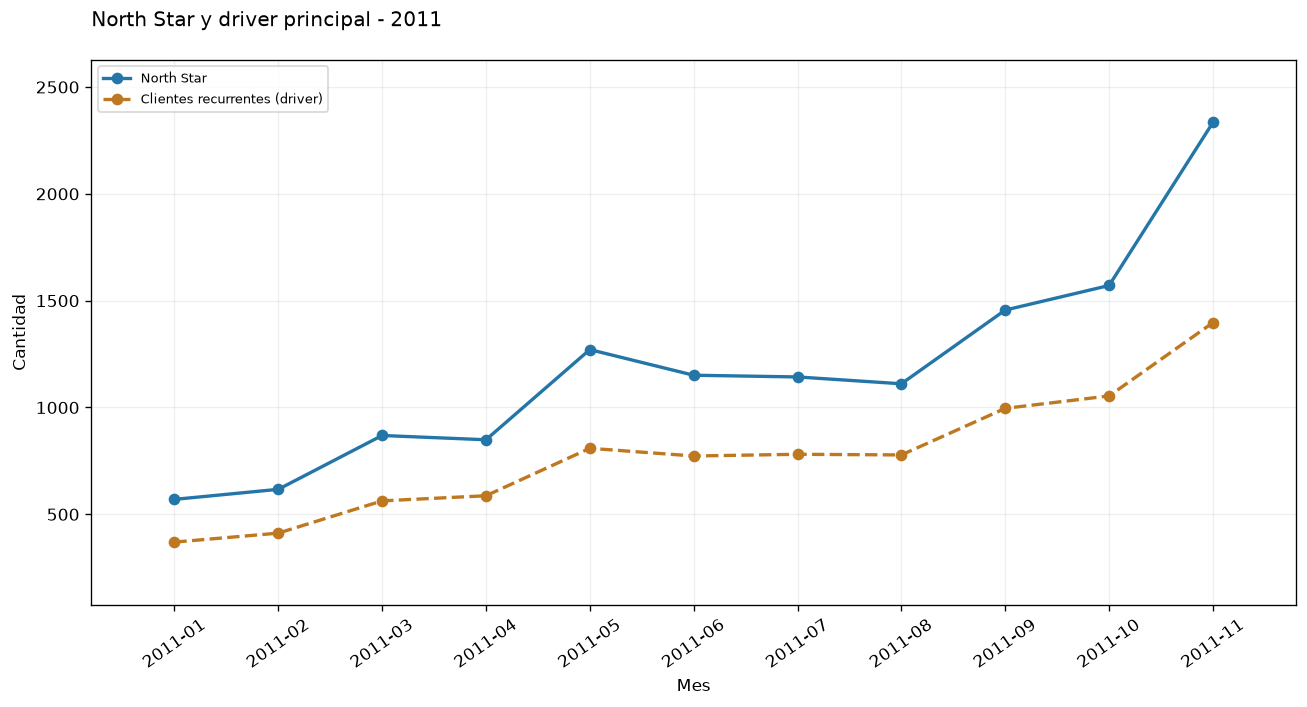

In [13]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=kpi["mes"].to_list(), y=kpi["compras_recurrentes"].to_list(),
                         mode="lines+markers", name="North Star"))

# El tablero incorpora el driver principal junto al resultado: un tablero que
# muestra la North Star sin su driver no permite decidir donde actuar.
fig.add_trace(go.Scatter(x=kpi["mes"].to_list(), y=kpi["clientes_recurrentes"].to_list(),
                         mode="lines+markers", name="Clientes recurrentes (driver)"))

fig.update_layout(title="North Star y driver principal - 2011", xaxis_title="Mes",
                  yaxis_title="Cantidad", hovermode="x unified")
fig.update_layout(template="plotly_white", font=dict(family="Arial", size=13),
    width=1050, height=560, margin=dict(l=85, r=65, t=105, b=90),
    legend=dict(orientation="h", y=-0.20, x=0), title=dict(x=0.04))
for j, trace in enumerate(fig.data):
    trace.update(marker=dict(color=["#2476A8", "#BE781F"][j % 2]),
                 line=dict(color=["#2476A8", "#BE781F"][j % 2]))
mostrar_grafico(fig)


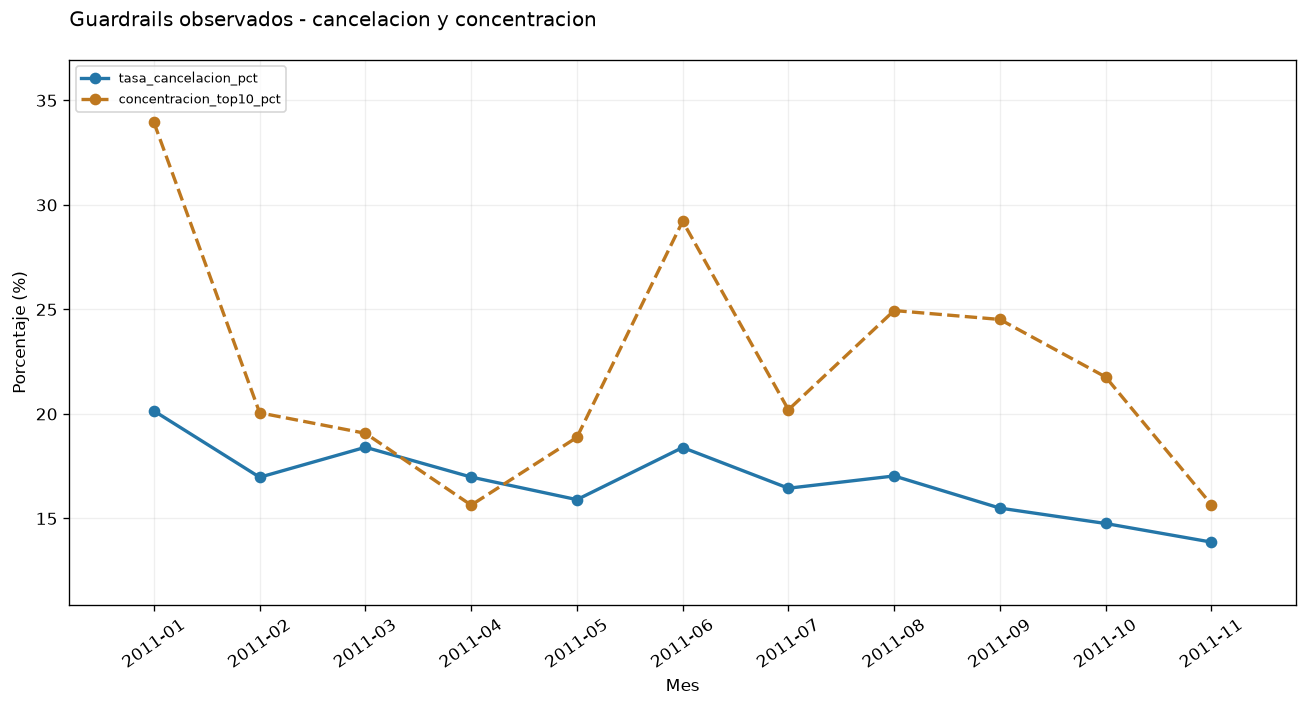

In [14]:
fig2 = px.line(kpi.to_pandas(), x="mes", y=["tasa_cancelacion_pct", "concentracion_top10_pct"],
               markers=True, title="Guardrails observados - cancelacion y concentracion")
fig2.update_layout(yaxis_title="Porcentaje (%)", xaxis_title="Mes", legend_title_text="Guardrail")
fig2.update_layout(template="plotly_white", font=dict(family="Arial", size=13),
    width=1050, height=560, margin=dict(l=85, r=65, t=105, b=90),
    legend=dict(orientation="h", y=-0.20, x=0), title=dict(x=0.04))
for j, trace in enumerate(fig2.data):
    trace.update(marker=dict(color=["#2476A8", "#BE781F"][j % 2]),
                 line=dict(color=["#2476A8", "#BE781F"][j % 2]))
mostrar_grafico(fig2)


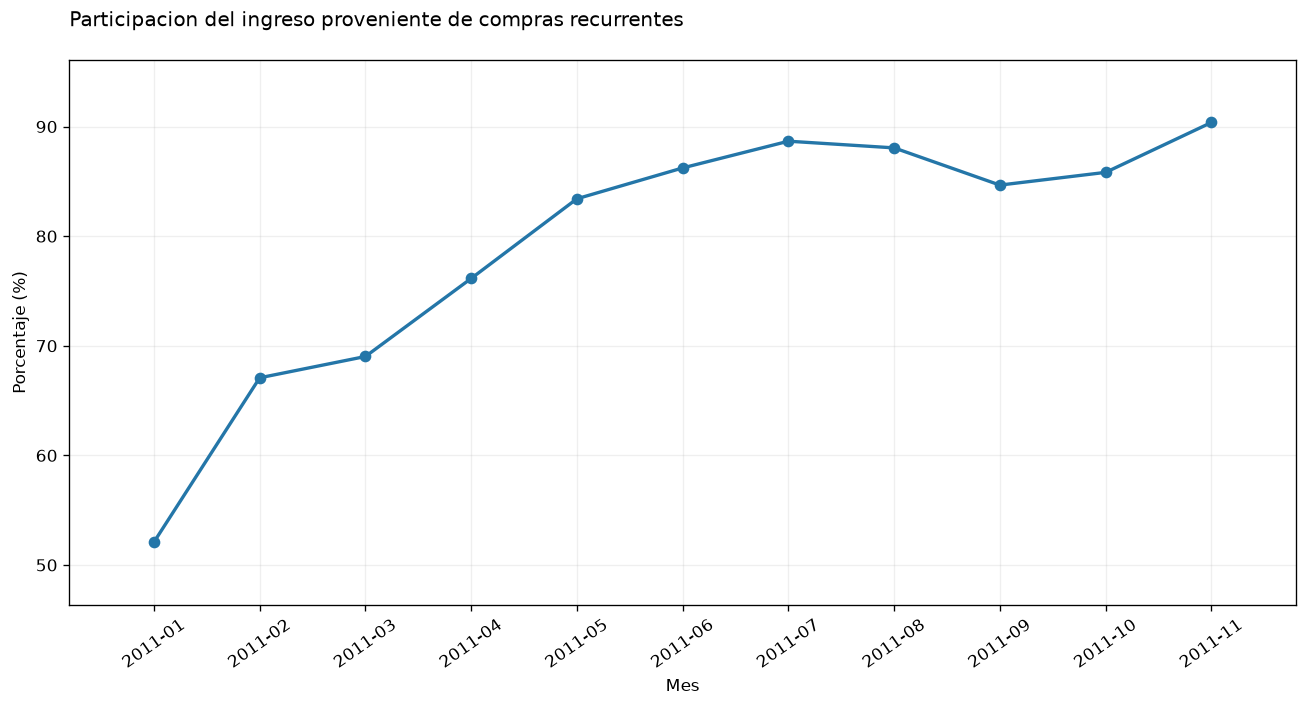

In [15]:
fig3 = px.line(kpi.to_pandas(), x="mes", y=["participacion_ingreso_recurrente_pct"],
               markers=True, title="Participacion del ingreso proveniente de compras recurrentes")
fig3.update_layout(yaxis_title="Porcentaje (%)", xaxis_title="Mes")
fig3.update_layout(template="plotly_white", font=dict(family="Arial", size=13),
    width=1050, height=560, margin=dict(l=85, r=65, t=105, b=90),
    legend=dict(orientation="h", y=-0.20, x=0), title=dict(x=0.04))
for j, trace in enumerate(fig3.data):
    trace.update(marker=dict(color=["#2476A8", "#BE781F"][j % 2]),
                 line=dict(color=["#2476A8", "#BE781F"][j % 2]))
mostrar_grafico(fig3)


### Interpretación obligatoria
No basta con decir “la línea bajó”. Responda:
1. ¿Cuánto cambió y en qué periodo?
2. ¿Cómo se comportó el driver principal?
3. ¿Algún guardrail empeoró al mismo tiempo?
4. ¿Qué puede afirmarse como evidencia y qué es solo una inferencia?
5. ¿Quién debería decidir y qué acción ejecutaría?

**Respuesta:**

1. Entre **mayo y junio**, las compras recurrentes bajan de **1 271 a 1 151**: 120 compras menos, equivalentes a **−9,44 %**.
2. Los clientes recurrentes bajan de **809 a 773 (−4,45 %)** y la frecuencia pasa de **1,571 a 1,489 (−5,22 %)**. Ambos componentes explican aritméticamente la caída.
3. La cancelación sube de **15,90 % a 18,39 % (+2,49 puntos porcentuales)** y la concentración Top 10 pasa de **18,88 % a 29,22 % (+10,34 puntos)**.
4. Es evidencia que el volumen recurrente cae y los guardrails empeoran simultáneamente. Que exista una falla de servicio o una pérdida de interés es una hipótesis: no hay información suficiente para probarla.
5. El responsable comercial debería coordinar con operaciones la revisión de anulaciones y de clientes que redujeron compras, segmentar los casos y probar una acción de reactivación acotada. Evaluaría recurrencia, cancelación y margen antes de escalarla.

## Reto 2 — Diagnóstico sin confundir correlación con causalidad


In [16]:
# Mes con mayor caida porcentual de la North Star.
# Se excluye el mes de calentamiento y el primero comparado contra el.
peor = (kpi.filter((pl.col("mes") > "2011-02") & pl.col("var_ns_pct").is_not_null())
        .sort("var_ns_pct")
        .head(1))
print("Mayor caida mensual de la North Star")
display(peor.select(["mes", "var_ns_pct", "var_clientes_rec_pct", "var_frecuencia_pct",
                     "tasa_cancelacion_pct", "concentracion_top10_pct"]))

# Febrero se compara contra enero (calentamiento); también se excluye del diagnóstico.


Mayor caida mensual de la North Star


mes,var_ns_pct,var_clientes_rec_pct,var_frecuencia_pct,tasa_cancelacion_pct,concentracion_top10_pct
str,f64,f64,f64,f64,f64
"""2011-06""",-9.441385,-4.449938,-5.223907,18.394845,29.2166


A partir de la salida anterior, escriba una conclusión en tres capas:

- **Evidencia:** lo que muestran los datos.
- **Inferencia:** explicación plausible, sin afirmar causalidad.
- **Decisión:** acción concreta que debería evaluar el responsable.

**Respuesta:**

- **Evidencia:** en junio la North Star cae **9,44 %**; disminuyen clientes recurrentes **4,45 %** y frecuencia **5,22 %**, con cancelación de **18,39 %** y concentración Top 10 de **29,22 %**.
- **Inferencia:** la menor frecuencia y una posible fricción operativa podrían coincidir con el deterioro. La estacionalidad o el cambio de mezcla de clientes también son explicaciones posibles; no puedo atribuir causalidad con agregados mensuales.
- **Decisión:** revisar una muestra de cancelaciones y segmentar compradores de mayo que redujeron actividad en junio. Proponer una prueba de reactivación con grupo de comparación y evaluar compras incrementales, cancelación y margen antes de generalizar.

## Diccionario de KPI

| KPI | Fórmula y unidad | Fuente y frecuencia | Responsable propuesto | Meta o alerta académica | Acción |
|---|---|---|---|---|---|
| Compras recurrentes/mes | Facturas válidas posteriores a la primera compra; número/mes. | UCI, `facturas`; mensual. | Responsable comercial. | Meta: +5 % frente al mes comparable anterior; alerta: variación negativa. | Separar efecto de clientes y frecuencia; revisar segmentos con caída. |
| Clientes recurrentes activos | Clientes distintos con al menos una factura recurrente del mes; clientes/mes. | UCI, `facturas`; mensual. | Responsable de CRM. | Meta: +3 % mensual; alerta: caída >3 %. | Revisar cohortes y ensayar reactivación con evaluación incremental. |
| Frecuencia recurrente | Compras recurrentes / clientes recurrentes activos; compras/cliente/mes. | UCI, `kpi`; mensual. | Responsable de fidelización. | Meta: al menos 1,50; alerta: caída >5 %. | Revisar experiencia y disponibilidad antes de promover nuevas compras. |
| Tasa de cancelación | 100 × facturas con prefijo C / total de facturas de clientes identificados del mes; %. | UCI, `base_total`; mensual. | Responsable de operaciones. | Alerta: >17 %; meta: ≤17 %. | Auditar causas de anulación y corregir los problemas confirmados. |
| Concentración Top 10 | 100 × ingreso de los diez clientes principales / ingreso válido del mes; %. | UCI, `cliente_mes`; mensual. | Responsable comercial y de riesgos. | Alerta: >25 %; meta: ≤25 %. | Evaluar dependencia y ampliar la base sin deteriorar calidad o margen. |

Estas metas, alertas y responsabilidades son **supuestos de gestión para el ejercicio**, no políticas oficiales de la empresa. Los ingresos corresponden a compras positivas, no al ingreso neto después de devoluciones. No se usa enero ni febrero para evaluar el crecimiento contra una base de calentamiento.


---

## Reto de aplicación y retroalimentación

En esta sección se aplicarán los procedimientos desarrollados durante la sesión a nuevas situaciones de análisis. Cada ejercicio requiere modificar, completar o construir código a partir de las tablas ya procesadas. Posteriormente, los resultados obtenidos deberán interpretarse brevemente desde una perspectiva empresarial. El propósito es comprobar la comprensión de las técnicas utilizadas y fortalecer la capacidad de adaptar el análisis ante nuevas preguntas de negocio.

**Indicaciones generales.** Los ejercicios operan sobre `kpi_reto`, copia de trabajo de la tabla de KPI, y sobre `facturas`, ya construida en la Actividad 2. Los datos proceden íntegramente del repositorio UCI; no corresponde generar ni sustituir valores en ningún caso. Cada respuesta escrita no debe exceder cuatro líneas.

**Duración en sesión:** 25 minutos. Los ejercicios que no concluyan se completan como avance del entregable.


In [17]:
# Copia de trabajo para la sección de retos.
kpi_reto = kpi.clone()
print("Copia de trabajo creada:", kpi_reto.shape)
print("Columnas disponibles:", kpi_reto.columns)
display(kpi_reto.head())


Copia de trabajo creada: (11, 16)
Columnas disponibles: ['mes', 'facturas_validas', 'clientes_activos', 'ingresos', 'compras_recurrentes', 'clientes_recurrentes', 'ingresos_recurrentes', 'frecuencia_recurrente', 'participacion_ingreso_recurrente_pct', 'ns_reconstruida', 'error_reconstruccion', 'tasa_cancelacion_pct', 'concentracion_top10_pct', 'var_ns_pct', 'var_clientes_rec_pct', 'var_frecuencia_pct']


mes,facturas_validas,clientes_activos,ingresos,compras_recurrentes,clientes_recurrentes,ingresos_recurrentes,frecuencia_recurrente,participacion_ingreso_recurrente_pct,ns_reconstruida,error_reconstruccion,tasa_cancelacion_pct,concentracion_top10_pct,var_ns_pct,var_clientes_rec_pct,var_frecuencia_pct
str,u32,u32,f64,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""2011-01""",987,741,569445.04,570,370,296614.01,1.540541,52.088259,570.0,0.0,20.145631,33.944082,null,null,null
"""2011-02""",997,758,447137.35,617,412,299937.36,1.497573,67.079469,617.0,0.0,16.971714,20.054254,8.245614,11.351351,-2.789133
"""2011-03""",1321,974,595500.76,869,563,411030.13,1.543517,69.022604,869.0,0.0,18.406424,19.073929,40.842788,36.650485,3.067901
"""2011-04""",1149,856,469200.361,849,587,357273.97,1.446337,76.145289,849.0,1.1369e-13,16.979769,15.638458,-2.301496,4.262877,-6.295983
"""2011-05""",1555,1056,678594.56,1271,809,566039.71,1.571075,83.413535,1271.0,0.0,15.900487,18.880129,49.705536,37.819421,8.624412


### Ejercicio 1 — Construcción de una tasa de recurrencia mensual

La North Star del laboratorio se expresa en cantidad de compras recurrentes, magnitud absoluta que crece cuando aumenta la actividad total del negocio. Una magnitud absoluta, sin embargo, no permite distinguir si la recurrencia mejora o si simplemente hay más transacciones de cualquier tipo.

La tasa de recurrencia corrige esa limitación: expresa qué proporción de las facturas del mes corresponde a clientes que ya habían comprado con anterioridad. Se trata de una magnitud relativa y, por tanto, comparable entre meses de distinto volumen.

**Se solicita:**

1. Calcular, para cada mes, la cantidad total de facturas y la cantidad de facturas recurrentes a partir de `facturas`.
2. Construir la tasa de recurrencia mensual expresada en porcentaje e incorporarla a `kpi_reto`.
3. Identificar el mes con la tasa más alta y el mes con la tasa más baja.
4. Comparar el ordenamiento por tasa de recurrencia con el ordenamiento por compras recurrentes.

**Tiempo estimado:** 5 minutos.


In [18]:
recurrencia = (facturas.group_by("mes")
    .agg(pl.col("InvoiceNo").n_unique().alias("total_facturas_reto"),
         pl.col("InvoiceNo").filter(pl.col("es_recurrente")).n_unique().alias("facturas_recurrentes_reto"))
    .with_columns((100 * pl.col("facturas_recurrentes_reto") / pl.col("total_facturas_reto")).alias("tasa_recurrencia_pct")))
kpi_reto = kpi_reto.join(recurrencia, on="mes", how="left")
display(kpi_reto.select("mes", "compras_recurrentes", "tasa_recurrencia_pct").sort("tasa_recurrencia_pct", descending=True))
print("Orden por cantidad:", kpi_reto.sort("compras_recurrentes", descending=True)["mes"].to_list())
print("Orden por tasa:", kpi_reto.sort("tasa_recurrencia_pct", descending=True)["mes"].to_list())

mes,compras_recurrentes,tasa_recurrencia_pct
str,u32,f64
"""2011-11""",2334,87.843432
"""2011-08""",1111,86.796875
"""2011-07""",1143,85.875282
"""2011-09""",1456,82.962963
"""2011-06""",1151,82.627423
"""2011-05""",1271,81.736334
"""2011-10""",1571,81.441161
"""2011-04""",849,73.890339
"""2011-03""",869,65.783497


Orden por cantidad: ['2011-11', '2011-10', '2011-09', '2011-05', '2011-06', '2011-07', '2011-08', '2011-03', '2011-04', '2011-02', '2011-01']
Orden por tasa: ['2011-11', '2011-08', '2011-07', '2011-09', '2011-06', '2011-05', '2011-10', '2011-04', '2011-03', '2011-02', '2011-01']


**Pregunta 3.** ¿Coincide el mes con mayor cantidad de compras recurrentes con el mes de mayor tasa de recurrencia? Explique qué implicancia tiene esa diferencia para la medición del negocio.

**Respuesta:**

Sí. **Noviembre** tiene el mayor volumen (**2 334 compras recurrentes**) y la mayor tasa (**87,84 %**); enero tiene la menor tasa (**57,75 %**). La coincidencia del máximo no hace equivalentes ambas medidas: agosto tiene una tasa de **86,80 %** con 1 111 compras, mientras septiembre registra **82,96 %** con 1 456. Por eso evalúo volumen y proporción conjuntamente, considerando el sesgo de historial de enero.

### Ejercicio 2 — Incorporación del ticket promedio como driver económico

El árbol de métricas descompuso la North Star en clientes recurrentes y frecuencia de compra. Ninguno de esos dos drivers recoge el valor económico de cada transacción: dos meses con idéntica cantidad de compras recurrentes pueden presentar ingresos muy distintos si el importe promedio de la factura cambia.

El ticket promedio de la factura recurrente completa esa descripción y permite establecer si el crecimiento observado proviene de mayor actividad o de mayor valor por transacción.

**Se solicita:**

1. Calcular, a partir de `facturas`, el importe promedio de las facturas recurrentes de cada mes.
2. Incorporar el resultado a `kpi_reto` en la columna `ticket_promedio_recurrente`.
3. Calcular su variación mensual porcentual, siguiendo el mismo procedimiento empleado para los demás drivers.
4. Contrastar los meses de mayor caída de la North Star con el comportamiento del ticket promedio en esos mismos meses.

**Tiempo estimado:** 5 minutos.


In [19]:
ticket = (facturas.filter(pl.col("es_recurrente")).group_by("mes")
    .agg(pl.col("importe_factura").mean().alias("ticket_promedio_recurrente")))
kpi_reto = kpi_reto.join(ticket, on="mes", how="left").sort("mes")
kpi_reto = kpi_reto.with_columns((100 * (pl.col("ticket_promedio_recurrente") / pl.col("ticket_promedio_recurrente").shift(1) - 1)).alias("var_ticket_pct"))
display(kpi_reto.filter(pl.col("mes") > "2011-02").sort("var_ns_pct")
    .select("mes", "var_ns_pct", "ticket_promedio_recurrente", "var_ticket_pct", "ingresos_recurrentes"))

mes,var_ns_pct,ticket_promedio_recurrente,var_ticket_pct,ingresos_recurrentes
str,f64,f64,f64,f64
"""2011-06""",-9.441385,495.34318,11.225621,570140.0
"""2011-08""",-2.79965,511.488461,9.877679,568263.68
"""2011-04""",-2.301496,420.817397,-11.030776,357273.97
"""2011-07""",-0.695048,465.507157,-6.023304,532074.68
"""2011-10""",7.898352,567.77492,2.478765,891974.4
"""2011-09""",31.053105,554.041532,8.319459,806684.471
"""2011-03""",40.842788,472.992094,-2.700977,411030.13
"""2011-11""",48.567791,449.864949,-20.767027,1.0500e6
"""2011-05""",49.705536,445.34989,5.829724,566039.71


**Pregunta 4.** En el mes de mayor caída de la North Star, ¿el ticket promedio recurrente aumentó o disminuyó? ¿Qué sugiere ese comportamiento conjunto?

**Respuesta:**

En **junio**, el ticket recurrente aumenta **11,23 %**, de **445,35 a 495,34 GBP**, aunque las compras caen **9,44 %**. Los ingresos recurrentes pasan de **566 039,71 a 570 140,00 GBP (+0,72 %)**: el mayor ticket compensa el menor volumen. Esto sugiere un cambio en el valor o mezcla de compras, sin demostrar una subida de precios ni mayor satisfacción.

### Ejercicio 3 — Definición de un guardrail de dependencia del cliente principal

La Actividad 2 incorporó un guardrail de concentración sobre los diez principales clientes. Ese umbral describe la dependencia agregada del negocio, pero no revela si dicha concentración se explica por un único cliente de gran tamaño, situación que constituye un riesgo operativo de naturaleza distinta.

Un guardrail de dependencia del cliente principal mide qué proporción del ingreso mensual corresponde al cliente de mayor facturación. Su finalidad no es optimizarse, sino advertir cuando la concentración alcanza un nivel que compromete la continuidad del negocio.

**Se solicita:**

1. Calcular, para cada mes, el ingreso del cliente de mayor facturación. La tabla `ordenado` ya dispone de la columna `ranking` calculada dentro de cada mes.
2. Expresar ese ingreso como porcentaje del ingreso total del mes e incorporarlo a `kpi_reto`.
3. Declarar explícitamente un umbral de alerta como criterio pedagógico del ejercicio, no como norma sectorial.
4. Identificar los meses que superan dicho umbral.

**Tiempo estimado:** 5 minutos.


In [20]:
UMBRAL_TOP1_PCT = 10.0  # Supuesto pedagógico; no es una norma sectorial.
top1 = (ordenado.group_by("mes")
    .agg(pl.col("ingreso_cliente").filter(pl.col("ranking") == 1).sum().alias("ingreso_top1"),
         pl.col("ingreso_cliente").sum().alias("ingreso_total_top1"))
    .with_columns((100 * pl.col("ingreso_top1") / pl.col("ingreso_total_top1")).alias("dependencia_top1_pct")))
kpi_reto = kpi_reto.join(top1, on="mes", how="left").sort("mes")
kpi_reto = kpi_reto.with_columns((pl.col("dependencia_top1_pct") > UMBRAL_TOP1_PCT).alias("alerta_top1"))
display(kpi_reto.select("mes", "ingreso_top1", "dependencia_top1_pct", "alerta_top1"))
print("Meses que superan el umbral:", kpi_reto.filter("alerta_top1").height)

mes,ingreso_top1,dependencia_top1_pct,alerta_top1
str,f64,f64,bool
"""2011-01""",77183.6,13.554179,true
"""2011-02""",22797.46,5.098536,false
"""2011-03""",21462.4,3.604093,false
"""2011-04""",21535.9,4.589915,false
"""2011-05""",28408.14,4.18632,false
"""2011-06""",41959.44,6.345821,false
"""2011-07""",26464.99,4.410163,false
"""2011-08""",40327.81,6.249042,false
"""2011-09""",75412.64,7.914526,false


Meses que superan el umbral: 1


**Pregunta 5.** ¿En cuántos meses el cliente principal supera el umbral declarado y qué decisión empresarial justificaría ese resultado?

**Respuesta:**

Con el umbral académico de **10 %**, el cliente principal lo supera en **1 de 11 meses: enero, con 13,55 %**. Revisaría la exposición a ese comprador y la posibilidad de diversificar ingresos; no eliminaría sus ventas. La alerta es una señal para investigar dependencia, no una norma sectorial ni una demostración de pérdida futura.

### Ejercicio 4 — Consulta de meses saludables con condiciones múltiples en DuckDB

En la Actividad 2 se empleó DuckDB para ordenar los meses según la variación de la North Star. Una consulta orientada a la decisión, sin embargo, no se limita a ordenar: delimita el subconjunto de periodos que satisfacen simultáneamente el objetivo de crecimiento y las restricciones fijadas por los guardrails.

Un mes de crecimiento acompañado de un deterioro en la tasa de cancelación no constituye un mes saludable. Esta consulta materializa esa distinción en una regla reproducible.

**Se solicita:**

1. Construir sobre `kpi_reto` una consulta SQL que incluya `SELECT`, `WHERE`, condiciones múltiples enlazadas con `AND` y `ORDER BY`.
2. Establecer como criterios una variación de la North Star positiva y una tasa de cancelación inferior al promedio del periodo.
3. Ordenar el resultado por variación de la North Star de mayor a menor.
4. Determinar cuántos meses satisfacen ambos criterios.

**Tiempo estimado:** 5 minutos.


In [21]:
# Regla literal del ejercicio: crecimiento positivo y cancelación bajo la media simple mensual.
saludables = duckdb.sql("""
SELECT mes, compras_recurrentes, var_ns_pct, tasa_cancelacion_pct
FROM kpi_reto
WHERE var_ns_pct > 0
  AND tasa_cancelacion_pct < (SELECT AVG(tasa_cancelacion_pct) FROM kpi_reto)
ORDER BY var_ns_pct DESC
""").pl()
display(saludables)
print("Meses saludables (regla solicitada):", saludables.height)
print("Promedio mensual de cancelación (%):", kpi_reto["tasa_cancelacion_pct"].mean())
# Sensibilidad: enero es calentamiento y febrero usa enero como base.
print("Excluyendo comparaciones contra calentamiento:", saludables.filter(pl.col("mes") > "2011-02").height)

mes,compras_recurrentes,var_ns_pct,tasa_cancelacion_pct
str,u32,f64,f64
"""2011-05""",1271,49.705536,15.900487
"""2011-11""",2334,48.567791,13.869086
"""2011-09""",1456,31.053105,15.495669
"""2011-10""",1571,7.898352,14.759169


Meses saludables (regla solicitada): 4
Promedio mensual de cancelación (%): 16.763947948019474
Excluyendo comparaciones contra calentamiento: 4


**Pregunta 6.** ¿Cuántos meses del periodo pueden calificarse como saludables según los criterios establecidos y qué sugiere esa proporción sobre la solidez del crecimiento?

**Respuesta:**

Cumplen la regla **4 de 11 meses (36,36 %): mayo, septiembre, octubre y noviembre**; la cancelación se compara con la media simple mensual de **16,76 %**. Son también **4 de 9 comparaciones (44,44 %)** al excluir enero y febrero por calentamiento. La mejora no es uniforme, y “saludable” aquí solo significa cumplir estos dos criterios, no asegurar rentabilidad ni ausencia de otros riesgos.

### Ejercicio 5 — Representación de la relación entre el driver y la North Star

El tablero construido en la Actividad 2 presenta la North Star y su driver como series temporales paralelas. Esa disposición permite observar la evolución de ambas magnitudes, pero no muestra con claridad si sus variaciones se corresponden entre sí.

Un gráfico de dispersión que enfrente la variación del driver con la variación de la North Star hace visible esa correspondencia: los puntos alineados sobre una tendencia ascendente indican que el driver acompaña el movimiento del resultado, mientras que los puntos dispersos advierten que otros factores intervienen. Corresponde recordar que la correspondencia observada describe una asociación y no acredita una relación causal.

**Se solicita:**

1. Construir con Plotly un gráfico de dispersión que sitúe la variación porcentual de clientes recurrentes en el eje horizontal y la variación porcentual de la North Star en el eje vertical.
2. Identificar cada punto con el mes correspondiente.
3. Rotular los ejes y titular el gráfico de modo que resulte interpretable sin recurrir al código.
4. Excluir de manera explícita el mes de calentamiento, que carece de variación calculable.

**Tiempo estimado:** 5 minutos.


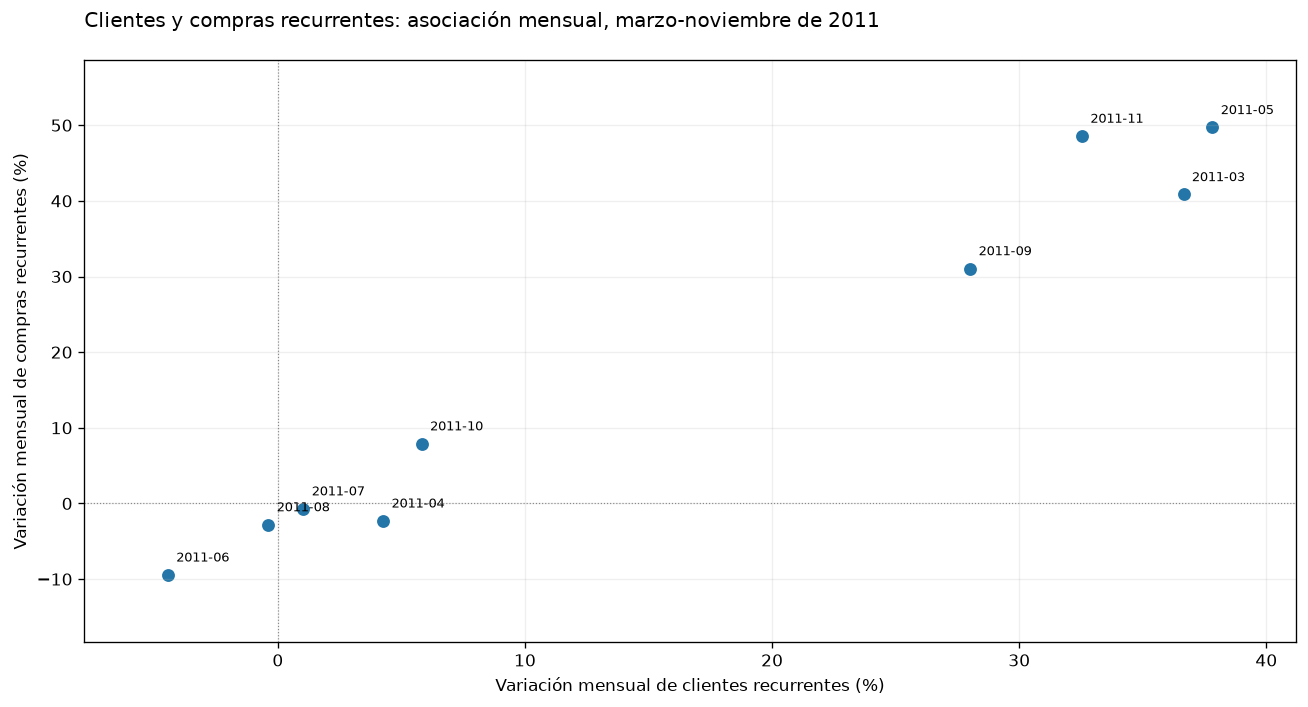

mes,var_clientes_rec_pct,var_ns_pct,var_frecuencia_pct
str,f64,f64,f64
"""2011-03""",36.650485,40.842788,3.067901
"""2011-04""",4.262877,-2.301496,-6.295983
"""2011-05""",37.819421,49.705536,8.624412
"""2011-06""",-4.449938,-9.441385,-5.223907
"""2011-07""",1.034929,-0.695048,-1.712256
"""2011-08""",-0.384123,-2.79965,-2.424841
"""2011-09""",28.020566,31.053105,2.368791
"""2011-10""",5.823293,7.898352,1.960871
"""2011-11""",32.542694,48.567791,12.090517


In [22]:
# Se excluyen enero (sin variación) y febrero (base enero en calentamiento).
dispersion = kpi_reto.filter((pl.col("mes") > "2011-02") & pl.col("var_ns_pct").is_not_null())
fig_reto = px.scatter(dispersion.to_pandas(), x="var_clientes_rec_pct", y="var_ns_pct", text="mes",
    hover_data=["var_frecuencia_pct"],
    labels={"var_clientes_rec_pct": "Variación mensual de clientes recurrentes (%)",
            "var_ns_pct": "Variación mensual de compras recurrentes (%)"},
    title="Clientes y compras recurrentes: asociación mensual, marzo-noviembre de 2011")
fig_reto.update_traces(textposition="top center")
fig_reto.add_hline(y=0, line_dash="dot", line_color="gray")
fig_reto.add_vline(x=0, line_dash="dot", line_color="gray")
fig_reto.update_layout(height=550, margin=dict(t=90))
fig_reto.update_layout(template="plotly_white", font=dict(family="Arial", size=13),
    width=1050, height=560, margin=dict(l=85, r=65, t=105, b=90),
    legend=dict(orientation="h", y=-0.20, x=0), title=dict(x=0.04))
for j, trace in enumerate(fig_reto.data):
    trace.update(marker=dict(color=["#2476A8", "#BE781F"][j % 2]),
                 line=dict(color=["#2476A8", "#BE781F"][j % 2]))
mostrar_grafico(fig_reto)
display(dispersion.select("mes", "var_clientes_rec_pct", "var_ns_pct", "var_frecuencia_pct"))

**Pregunta 7.** ¿La variación del driver acompaña la variación de la North Star? Indique un mes que se aparte de esa correspondencia y proponga una explicación verificable.

**Respuesta:**

La variación de clientes recurrentes suele acompañar la North Star, pero **abril** se aparta: clientes **+4,26 %** y compras **−2,30 %**. La frecuencia cae **6,30 %**, lo que reconcilia ambos movimientos mediante la identidad del árbol. Verificaría si hay menos compras por cliente en segmentos concretos; esa relación aritmética no prueba una causa comercial.

## Informe ejecutivo breve

1. **Objetivo estratégico:** incrementar las compras recurrentes sin deteriorar la calidad de la actividad ni elevar la dependencia de pocos clientes.
2. **North Star y justificación:** compras válidas de clientes recurrentes por mes; representa actividad repetida, admite acciones del equipo y se descompone en clientes y frecuencia.
3. **Hallazgo cuantitativo 1:** junio cae 9,44 % frente a mayo, de 1 271 a 1 151 compras; es la mayor caída mensual tras excluir el calentamiento y su primera comparación.
4. **Hallazgo cuantitativo 2:** los clientes recurrentes disminuyen 4,45 % y la frecuencia 5,22 %; priorizo revisar la frecuencia, sin ignorar la reducción de compradores activos.
5. **Hallazgo cuantitativo 3:** en junio la cancelación llega a 18,39 % y la concentración Top 10 a 29,22 %, frente a 15,90 % y 18,88 % en mayo.
6. **Driver prioritario:** frecuencia recurrente; el ticket crece 11,23 % y sostiene los ingresos recurrentes, pero no revierte la pérdida de actividad.
7. **Guardrails:** cancelación y concentración Top 10; complemento con alerta Top 1 de 10 % como supuesto académico.
8. **Decisión empresarial recomendada:** comercial y operaciones deben investigar cancelaciones y compradores con menor frecuencia, y probar una reactivación segmentada con grupo de comparación. Propongo medir compras incrementales durante 30 días y evitar escalar si empeoran cancelación o margen; no presento esta prueba como ya realizada.
9. **Limitaciones:** datos históricos de una sola empresa, clientes sin identificador excluidos, duplicados conservados, ausencia de costos, margen, satisfacción y motivos de cancelación. La recurrencia depende del historial disponible; la fuente no demuestra causalidad ni describe el mercado actual.


## Ticket de salida

Elija una métrica de su proyecto integrador. Explique por qué es accionable y qué decisión cambiaría si disminuyera 20 %.

**Respuesta:**

Para mi proyecto de detección de anomalías con Isolation Forest selecciono **Average Precision (AP)**, ya que en uno de mis proyectos obtuve **0,818**, según el resultado que registré. Es accionable si se calcula sobre una validación etiquetada, con la clase positiva y la proporción de anomalías claramente definidas; no debe interpretarse como accuracy ni como una métrica directamente calculable sin etiquetas.

Si disminuyera **20 % de forma relativa**, pasaría de **0,818 a 0,6544** (−0,1636 puntos de AP). Antes de reemplazar el modelo, verificaría calidad y distribución de los datos, etiquetas, transformación de variables y comparabilidad del conjunto de evaluación. Si el deterioro se confirma, compararía una nueva versión contra la base y revisaría precisión/recall en el umbral operativo. La decisión sería mantener la versión validada y no promover una actualización hasta recuperar el criterio acordado; esta es una propuesta, no una afirmación de despliegue en producción.

## Referencias

- Chen, D. (2015). *Online Retail* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5BW33  
- Croll, A., & Yoskovitz, B. (2013). *Lean Analytics*. O’Reilly Media.  
- Parmenter, D. (2020). *Key Performance Indicators* (4th ed.). Wiley.  
- Sharda, R., Delen, D., & Turban, E. (2024). *Business Intelligence, Analytics, Data Science, and AI* (5th ed.). Pearson.


In [23]:
# Controles de consistencia y exportación de evidencia.
assert kpi.height == 11 and kpi["mes"].n_unique() == 11
assert facturas.height == facturas["InvoiceNo"].n_unique()
assert kpi["error_reconstruccion"].abs().max() < 1e-8
assert (kpi_reto["facturas_recurrentes_reto"] == kpi_reto["compras_recurrentes"]).all()
for nombre in ["tasa_recurrencia_pct", "dependencia_top1_pct", "tasa_cancelacion_pct", "concentracion_top10_pct"]:
    assert kpi_reto[nombre].is_between(0, 100).all(), nombre
assert (kpi_reto["ticket_promedio_recurrente"] * kpi_reto["compras_recurrentes"] - kpi_reto["ingresos_recurrentes"]).abs().max() < 1e-6
from pathlib import Path
import json
carpeta = Path.cwd()
kpi_reto.write_csv(carpeta / "metricas_lab3.csv")
resumen = {"kpi": kpi_reto.to_dicts(), "saludables": saludables.to_dicts(),
 "filas": df.height, "columnas_originales": 8, "paises": df["Country"].n_unique(),
 "fechas": [str(df["InvoiceDate"].min()), str(df["InvoiceDate"].max())],
 "compras_validas": compras.height, "sin_cliente": df["CustomerID"].null_count(),
 "duplicados_exactos": df.height - df.unique().height}
(carpeta / "resultados_lab3.json").write_text(json.dumps(resumen, ensure_ascii=False, indent=2), encoding="utf-8")
fig_reto.write_html(carpeta / "grafico_reto5.html", include_plotlyjs=True)
print("Validación completada: identidad North Star, porcentajes, facturas únicas e ingreso recurrente reconciliados.")

Validación completada: identidad North Star, porcentajes, facturas únicas e ingreso recurrente reconciliados.
